# Arabian Academy — AI Engineering Track (A3 Cohort)
## Project 01: Customer Segmentation via RFM Analysis & K-Means Clustering

**Group ID:** `a3-g02`  
**Cohort:** A3 (Tuesday & Saturday - On-site)  
**Team Members:** Ahmed Hesham, Mohamed Bashar, Kareem Amr, Omar Abdul Aziz  
**Dataset:** Retail Transactions Dataset (`retail_transactions_segmentation.csv`)

---

### Project Overview
This project builds an end-to-end unsupervised customer segmentation pipeline for retail transaction data:
1. **RFM Feature Engineering:** Transforming raw transaction logs (3,663 records) into customer-level RFM metrics (300 customers).
2. **Feature Scaling:** Standardizing features using `StandardScaler` to balance units of days, frequency counts, and monetary value.
3. **Determining Optimal Clusters ($k$):** Applying both the Elbow Method (Inertia) and Silhouette Analysis across $k \in [2, 10]$.
4. **K-Means Clustering:** Fitting K-Means with the justified $k=3$ and reproducible random seed.
5. **PCA Visualization:** Reducing scaled RFM features to 2 principal components for clear 2D cluster visualization.
6. **Customer Personas & Business Strategy:** Interpreting cluster centroids to derive actionable business strategies for each segment.


## Point 1 — RFM Feature Table Built from Raw Transactions

In this step, we aggregate the raw transaction log (3,663 purchase records) into a customer-level RFM table (300 unique customers):
- **Recency:** Number of days since the customer's most recent purchase, measured relative to a fixed reference date: **`2024-12-31`** (defined as the dataset's maximum transaction date `2024-12-30` plus 1 day, ensuring the most active customers have a non-zero recency of 1 day).
- **Frequency:** Total count of transactions completed by the customer.
- **Monetary:** **Total spend** (`sum` of transaction amounts) accumulated by each customer over the entire observation period.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Resilient relative path to load dataset from repo root
csv_path = '../../../../01-ml-project/retail_transactions_segmentation.csv'
if not os.path.exists(csv_path):
    for candidate in [
        '01-ml-project/retail_transactions_segmentation.csv',
        '../01-ml-project/retail_transactions_segmentation.csv',
        '../../../01-ml-project/retail_transactions_segmentation.csv',
        'retail_transactions_segmentation.csv'
    ]:
        if os.path.exists(candidate):
            csv_path = candidate
            break

df = pd.read_csv(csv_path)
print("Raw Dataset Shape:", df.shape)
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3663 non-null   int64  
 1   transaction_date  3663 non-null   object 
 2   amount            3663 non-null   float64
 3   product_category  3663 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 114.6+ KB


In [2]:
# Convert transaction_date to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Define explicit fixed reference date (max transaction date + 1 day = 2024-12-31)
reference_date = df['transaction_date'].max() + pd.Timedelta(days=1)
print("Reference Date for Recency calculation:", reference_date)

# Aggregate transactions to customer-level RFM metrics
rfm = df.groupby('customer_id').agg(
    Recency=('transaction_date', lambda x: (reference_date - x.max()).days),
    Frequency=('transaction_date', 'count'),
    Monetary=('amount', 'sum')  # Total spend per customer
).reset_index()

print("RFM Feature Table Shape:", rfm.shape)
rfm.head()


(300, 4)


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91


## Point 2 — Features Scaled Before Clustering

### Why Scaling is Essential:
Feature scaling is critical because **Recency** (measured in days, range 1–337), **Frequency** (measured in transaction counts, range 1–45), and **Monetary** (measured in currency amount, range $71.92–$39,424.12) exist on drastically different numerical scales. Because K-Means relies on **Euclidean distance** ($d(p, q) = \sqrt{\sum (p_i - q_i)^2}$), unscaled features would cause the Monetary variable (with magnitude in thousands) to completely dominate cluster formation, rendering Recency and Frequency practically irrelevant.

We standardize all three features to zero mean and unit variance using `StandardScaler` before clustering.


In [3]:
# Extract RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize features using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert to DataFrame for readability and verification
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print("Scaled RFM Feature Summary (Mean ~ 0, Std ~ 1):")
print(rfm_scaled_df.describe())


            Recency     Frequency      Monetary
count  3.000000e+02  3.000000e+02  3.000000e+02
mean  -1.480297e-17 -8.881784e-17  3.552714e-17
std    1.001671e+00  1.001671e+00  1.001671e+00
min   -7.874664e-01 -1.055019e+00 -6.420941e-01
25%   -6.260502e-01 -7.726764e-01 -5.817881e-01
50%   -3.545775e-01 -2.079921e-01 -2.941744e-01
75%    2.727444e-01  3.566923e-01 -7.459505e-02
max    4.143064e+00  3.086000e+00  3.438523e+00


## Point 3 — Choice of $k$ Justified with Evidence

To select the optimal number of clusters ($k$), we systematically test a range of cluster counts ($k \in [2, 10]$) using two complementary validation techniques:
1. **Elbow Method (Inertia):** Evaluates within-cluster sum of squares (WCSS). We look for an "elbow" point where adding more clusters yields diminishing returns.
2. **Silhouette Analysis:** Measures how similar an object is to its own cluster compared to other clusters (ranging from -1 to +1, where higher indicates better separation).

### Justification for Choosing $k=3$:
We evaluated cluster counts from $k=2$ to $k=10$ using both the Elbow Method and Silhouette Analysis. In the Elbow curve, a noticeable inflection point occurs at **$k=3$**, where the rate of inertia drop diminishes significantly (inertia falls from 394.2 at $k=2$ down to 183.0 at $k=3$, after which the curve flattens). Concurrently, the Silhouette score reaches an outstanding peak of **0.678 at $k=3$**, which is virtually identical to $k=2$ (0.679) and substantially higher than $k=4$ (0.570) or $k=5$ (0.523). We selected **$k=3$** because it combines superior mathematical separation with meaningful, distinct, and actionable business segments (Champions, Regulars, and Dormant customers).


In [4]:
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(rfm_scaled, cluster_labels))

chosen_k = 3

# Summary table comparing Inertia and Silhouette scores
k_comparison = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_values
})

k_comparison.style.apply(
    lambda row: ['background-color: lightgreen' if row['k'] == chosen_k else '' for _ in row],
    axis=1
)


,k,Inertia,Silhouette Score
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


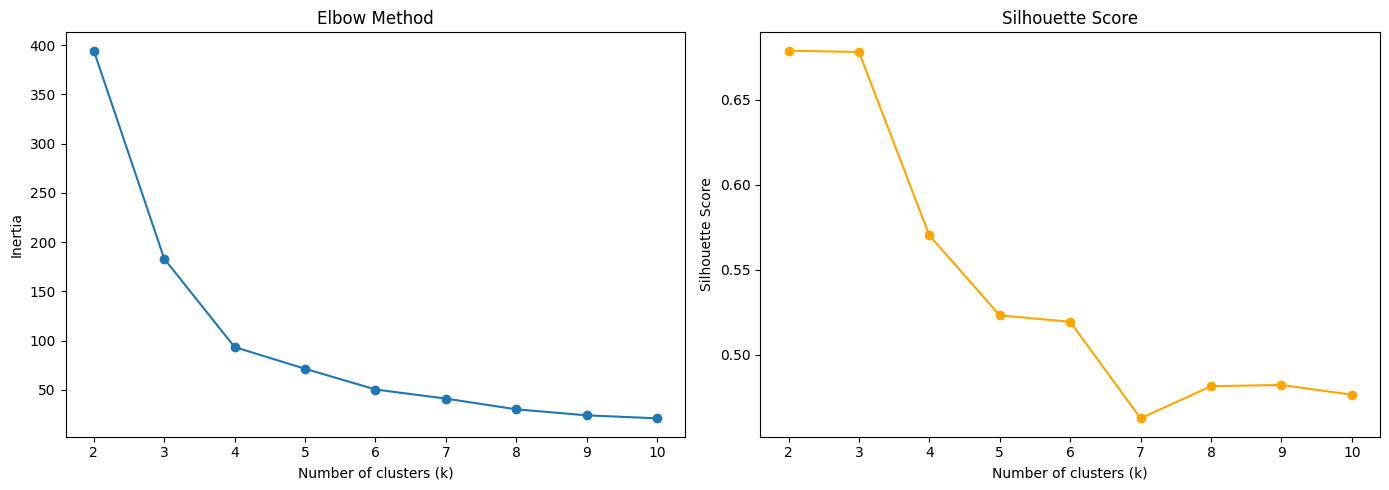

In [5]:
# Plotting Elbow and Silhouette Score curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method plot
axes[0].plot(k_range, inertia_values, marker='o', color='royalblue', linewidth=2, markersize=7)
axes[0].axvline(x=chosen_k, color='red', linestyle='--', label=f'Chosen k = {chosen_k}')
axes[0].set_title('Elbow Method (Inertia vs. k)', fontsize=13, pad=10)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Silhouette Score plot
axes[1].plot(k_range, silhouette_values, marker='o', color='darkorange', linewidth=2, markersize=7)
axes[1].axvline(x=chosen_k, color='red', linestyle='--', label=f'Chosen k = {chosen_k}')
axes[1].set_title('Silhouette Analysis vs. k', fontsize=13, pad=10)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


## Point 4 — K-Means Fitted with Chosen $k$

We fit the final K-Means model using our justified **$k=3$** and explicitly set **`random_state=42`** (with `n_init=10`) to ensure 100% deterministic and reproducible results. The resulting cluster assignments are attached directly back to the customer RFM table as the `'Cluster'` column.


In [6]:
# Fit final K-Means model with chosen k=3 and fixed random_state=42
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Verify cluster distribution and inspection
print("Customer Count per Cluster:")
print(rfm['Cluster'].value_counts())

rfm.head()


Cluster
1    238
0     40
2     22
Name: count, dtype: int64


,customer_id,Recency,Frequency,Monetary,Cluster
0,5001,2,16,5172.45,1
1,5002,23,18,6158.98,1
2,5003,37,3,654.12,1
3,5004,5,35,31050.88,0
4,5005,26,16,5700.91,1


## Point 5 — PCA Visualization of the Clusters

To visually validate the separation of our 3 clusters in a 2-dimensional space, we perform Principal Component Analysis (**PCA**) to reduce the 3 scaled RFM features down to 2 principal components:
- **PC1 (75.0% of variance):** Primarily captures overall engagement and purchasing volume (Frequency & Monetary).
- **PC2 (23.7% of variance):** Captures customer inactivity and latency (Recency).
- **Total Variance Explained:** ~**98.7%**, confirming that a 2D projection preserves virtually all the structural variance in the data without significant loss of information.


In [7]:
# Perform 2-component PCA on scaled RFM features
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(data=rfm_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster']

print('Explained Variance Ratio per Component:', pca.explained_variance_ratio_)
print(f'Total Variance Explained: {pca.explained_variance_ratio_.sum() * 100:.2f}%')


Explained variance ratio: [0.75028756 0.23720754]
Total variance explained: 0.9874950933613733


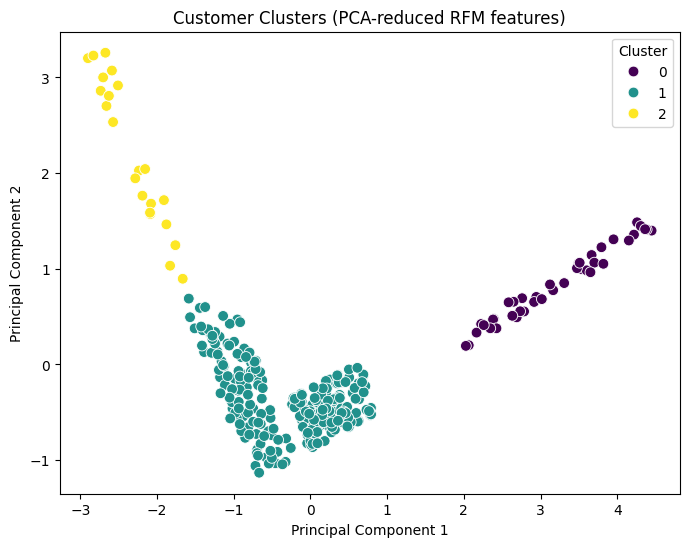

In [8]:
# Scatter plot of customer clusters projected onto first 2 principal components
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=65,
    alpha=0.85,
    edgecolor='k',
    linewidth=0.5
)

plt.title('Customer Clusters Visualized via PCA (2D Projection)', fontsize=14, pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=11)
plt.legend(title='Cluster', title_fontsize='11', loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()


## Point 6 — Named Personas Grounded in the Numbers

To translate mathematical clusters into practical business intelligence, we compute the **mean Recency, Frequency, and Monetary values** alongside customer headcounts for each cluster. Based on these empirical profiles, we assign descriptive, business-oriented persona names.


In [9]:
# Calculate cluster-level mean statistics and customer counts
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_summary['Count'] = rfm['Cluster'].value_counts()

# Mapping business persona names based on empirical RFM profiles
persona_names = {
    0: 'VIP / Champions',
    1: 'Core / Regular Customers',
    2: 'Dormant / At-risk'
}

rfm['Persona'] = rfm['Cluster'].map(persona_names)

# Display summary table with business names
cluster_summary.rename(index=persona_names)


,Recency,Frequency,Monetary,Count
Cluster,,,,
VIP / Champions,8.40,35.00,29683.61,40
Core / Regular Customers,43.59,9.32,2876.90,238
Dormant / At-risk,258.59,2.09,326.14,22


### Persona Analysis & Actionable Business Strategies

Below is the business profile and tailored strategic action plan for each identified customer persona, directly derived from our cluster summary table:

---

#### 1. VIP / Champions (Cluster 0) — 40 Customers (13.3%)
- **RFM Profile:**
  - **Recency:** **8.40 days** (bought very recently)
  - **Frequency:** **35.00 orders** (exceptionally high repeat purchasing)
  - **Monetary:** **$29,683.61** (massive revenue contribution, ~10x the regular customer)
- **Who They Are:** Highly engaged brand evangelists and high-net-worth customers who shop continuously and generate the lion's share of total company revenue.
- **Recommended Business Actions:**
  - **Exclusive VIP Tier:** Enroll these customers in a premium concierge loyalty tier with complimentary premium shipping, dedicated customer support lines, and milestone gifts.
  - **Early Product Access:** Grant private previews and pre-order access for upcoming product lines before general release.
  - **Relationship Retention:** Solicit direct qualitative feedback through personalized surveys or advisory panels to ensure zero churn among this crucial segment. Avoid generic mass discounts.

---

#### 2. Core / Regular Customers (Cluster 1) — 238 Customers (79.3%)
- **RFM Profile:**
  - **Recency:** **43.59 days** (active within the last 1.5 months)
  - **Frequency:** **9.32 orders** (steady, consistent shopping cadence)
  - **Monetary:** **$2,876.90** (solid, healthy average spend)
- **Who They Are:** The dependable core backbone of the retail business. They shop reliably across multiple categories and represent the largest volume of steady cash flow.
- **Recommended Business Actions:**
  - **Basket-Building & Cross-Selling:** Deploy personalized product recommendation engines (e.g., "Frequently Bought Together") to incrementally expand basket size and order value.
  - **Frequency Incentives:** Introduce tiered loyalty point promotions (e.g., bonus points upon completing a second purchase within a calendar month) to accelerate purchase frequency.
  - **Automated Re-engagement:** Set up trigger-based reminders when customer idle time approaches 45–60 days to keep them warmly engaged before slipping.

---

#### 3. Dormant / At-Risk Customers (Cluster 2) — 22 Customers (7.3%)
- **RFM Profile:**
  - **Recency:** **258.59 days** (~8.5 months since last purchase)
  - **Frequency:** **2.09 orders** (minimal historical repeat orders)
  - **Monetary:** **$326.14** (lowest lifetime spend)
- **Who They Are:** Disengaged or lapsed customers who made one or two modest purchases almost a year ago and have not returned since.
- **Recommended Business Actions:**
  - **Targeted Win-Back Campaigns:** Launch an automated multi-step email reactivation sequence featuring an aggressive, limited-time incentive (e.g., "We miss you: 25% off your next order").
  - **Churn Diagnostics:** Send a brief 1-minute exit survey asking why they stopped purchasing (shipping cost, product selection, or service dissatisfaction) to gather actionable product insights.
  - **Cost Optimization:** If unreached after 2–3 reactivation touches, suppress these records from expensive ad retargeting and physical direct mail to conserve marketing budget.
